**IMU**

*IMU data processing*

References:

1. Quaternion Kinematics for Error State Kalman Filter, Sola

2. VQF: Highly Accurate IMU Orientation Estimation with Bias Estimation and Magnetic Disturbance Rejection, Laidig & Seel,

Paper: https://arxiv.org/abs/2203.17024
Code: https://github.com/dlaidig/vqf


Please write your answers in the cells below For help with Latex notation, see this sites:

1. https://colab.research.google.com/github/bebi103a/bebi103a.github.io/blob/master/lessons/00/intro_to_latex.ipynb

2. https://oeis.org/wiki/List_of_LaTeX_mathematical_symbols

In [1]:
#@title DO NOT EDIT. Only run this cell to install the client to access the AI-TA
AI_TA_URL="https://ai-ta-326056429620.asia-south1.run.app/"
course_id="e9222"
notebook_id = "IMU"
institution_id="IISc"
term_id = "2025-26"
!pip install colab-grading-client
import colab_grading_client as ta

ModuleNotFoundError: No module named 'google.colab'

In [2]:
# @title DO NOT EDIT. Only run this cell to authenticate yourself. A separate window will open for this. copy the token and paste in the text box below and press enter key to complete the authentication. Sometimes text box doesnt display - in which case rerun the cell.
session=ta.authenticate(AI_TA_URL)

Paste your token here: ··········
Authenticated as: Dwaipayan Haldar (dwai.payan152002@gmail.com)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as spio
from scipy import signal
import math

**Runge-Kutta Integration**

Consider a Ordinary differential equation $\dot{y} = f(t,y)$

Then $y(t) = y(t_0) + \int_{t_0}^t f(t,y)dt$

To numerically integrate, we break up the time (x) axis into equal sized steps of size t and approximate the integral by a sum

$y(t) = \Sigma_{i=0}^{N} \int_{t_0+i\Delta t}^{t_0 + (i+1) \Delta t}f(t,y)dt$

The approximation becomes better as $N→\infty$

We can approximate the integral of each narrow time interval in various ways with trade-offs between accuracy and computation cost.

1. Euler integration

$\int_{t_n}^{t_{n+1}} f(t,y)dt \approx f(t_n,y_n)\Delta t$. (value at the beginning of the integral)

2. Trapezoidal integration

$\int_{t_n}^{t_{n+1}} f(t,y)dt \approx 1/2(f(t_n,y_n)+f(t_{n+1},y_{n+1})\Delta t$. (area of the trapezoid)

3.  Runge-Kutta order 4

Here we find slopes at start, midpoint and end of the interval as:

$k_1 = f(t_n, y_n)$

$k_2 = f(t_n+\Delta t/2, y_n+\frac{h}{2} k_1)$

$k_3 = f(t_n+\Delta t/2, y_n+\frac{h}{2} k_2)$

$k_4 = f(t_n+\Delta t, y_n+h k_3)$

$\int_{t_n}^{t_{n+1}} f(t,y)dt \approx 1/6(k_1+2k_2 + 2k_3 + k_4)\Delta t$


**Q1: 10**

Complete the code below for  RK1 (Euler) and RK4 and compare the errors when integrating  dx/dt = x, with initial condition of x(0)=1, in the interval [0,1]

Plot the error from both methods at t=1 vs. step size on a log-log scale and comment on the slope of the error with step size for euler and RK4.

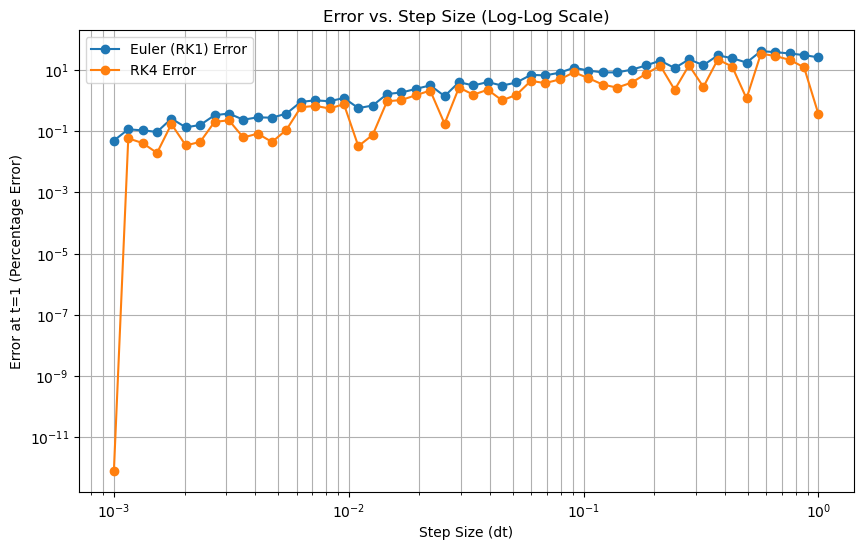

In [ ]:
## Ans:

def rk1(f,x0:float,ts:float,tf:float,dt:float):
  '''Runge-Kutta integration of order 1
  dx/dt = f(x(t))
  x(tf) = x(ts)+integration_ts^tf f(x(tau))dtau
  inputs:
  f: function to be evaluated
  x0: initial condition = x(ts)
  ts: initial time
  tf: final time
  dt: time step

  Output:
  x(tf)
  '''
  N=int((tf-ts)/dt)
  x = x0
  t = ts
  for i in range(N):
    x = x + dt * f(t, x)
    t = t + dt

  return x

def rk4(f,x0:float,ts:float,tf:float,dt:float):
  '''Runge-Kutta integration of order 4
  dx/dt = f(x(t))
  x(tf) = x(ts)+integration_ts^tf f(x(tau))dtau
  inputs:
  f: function to be evaluated
  x0: initial condition = x(ts)
  ts: initial time
  tf: final time
  dt: time step

  Output:
  x(tf)
  '''
  N=int((tf-ts)/dt)
  x = x0
  t = ts
  for i in range(N):
    k1 = f(t, x)
    k2 = f(t + dt/2, x + (dt/2) * k1)
    k3 = f(t + dt/2, x + (dt/2) * k2)
    k4 = f(t + dt, x + dt * k3)
    x = x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    t = t + dt

  return x

def f(t,x):
  '''
  dx/dt = f(t,x) = x
  x(t) = x(0)*exp(t)
  '''
  return x

ts = 0
tf = 1
dt = 0.05
x0 = 1.0

dt_array = np.logspace(-3, 0, 50)
x_exact = x0 * np.exp(tf)
euler_error = []
rk4_error = []
for dt in dt_array:
    x_euler = rk1(f, x0, ts, tf, dt)
    x_rk4   = rk4(f, x0, ts, tf, dt)
    euler_error.append(abs(x_euler - x_exact) / x_exact * 100)
    rk4_error.append(abs(x_rk4   - x_exact) / x_exact * 100)

plt.figure(figsize=(10, 6))
plt.loglog(dt_array, euler_error, '-o', label='Euler (RK1) Error')
plt.loglog(dt_array, rk4_error, '-o', label='RK4 Error')
plt.title('Error vs. Step Size (Log-Log Scale)')
plt.xlabel('Step Size (dt)')
plt.ylabel('Error at t=1 (Percentage Error)')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()


<your observation here>

The log log plot shows that RK4 error has a slope of 4 and hence error is proportional to fourth power of stepsize, while euler error slope is 1 indicating error here is linear with step size.

Hence RK4 is a better option to use when compute resources/budget permit.


**Chat with TA (do not delete this line)**

*You can ask the TA for help by replacing this sentence your query etc here and then clicking the button in the next cell*

In [ ]:
#@title Run this cell to get the button and then click it to get feedback from the TA about your answer and query/comment
ta.show_teaching_assist_button(session,AI_TA_URL, 1, notebook_id, institution_id, term_id, course_id)

---
**Poses & Transforms**

Assume that a rigid body has a locally defined coordinate frame - i.e. its own orthogonal x,y,z axes and an origin. We will refer to this as the B frame. Also there is a fixed world frame, W, with its own x,y,z axes and an origin.


As the body moves around in the world, the B frame also move around. We can track the position of the body by tracking its B frame. The B frame origin is displaced from the world origin by $p  \in ℝ^3$ and the B frame axes are oriented with respect to W frame axes and this orientation is specified via a Rotation matrix $R \in ℝ^{3\times 3}$

The pose of the body is the combination of orientation and translation and can be succintly represented as a 4x4 matrix as $^WT_B =\begin{bmatrix} ^WR_B  & ^Wp_B \\ 0 & 1 \end{bmatrix}$

$^WT_B$ not only allows us to represent the pose of the body in world frame, but it also can be used to transform points/vectors in the body frame into world frame as : $^Bv = ^WR_B\ \  ^Bv + ^Wp_B$

This is a bijective transformation and hence its inverse is $^BT_W = (^WT_B)^{-1} = \begin{bmatrix} R^T  & -R^Tp \\ 0 & 1 \end{bmatrix}$ where we are using $R=^WR_B$ and $p=^Wp_B$

Consequantly we can convert any vector/point in world frame into body vector as: $^Bv = ^BT^{-1}_W\ \ ^Wv$

In the rest of this lab, we will drop the superscripts B, G for convenience - unless there is a need to make the context explicit. We will assume that measurements sensors are onthe body and we are tracking the body's pose in the global frame.


As the body moves around, its pose is a function of time $T(t)$ (when we drop the subscripts/superscripts it is w.r.t world frame) and our central problem is to estimate this $\hat{T}(t) \approx T(t)$ using measurements via sensors mounted on the body (IMU, on-body cameras, wheel encoders, radar, lidar) or in the global frame (GPS, external cameras, radar, lidar)




---
**Pose State**

The sensors sample a physical signal $u(t)$ at a sampling rate of $f_s = \frac{1}{T_s}$ samples per second giving sensor readings of $u(kT_s)= u_k$.

The continuous pose state $T(t)$ is then represented as poses at discrete time steps $T_k$.

The poses are elements of the Lie Group SE(3) and represented as a 4x4 matrix as:

$T_k = \begin{bmatrix} R_k & p_k \\ 0 & 1 \end{bmatrix}_{4\times4}$

Here $R_k$ is a $3\times3$ rotation matrix and $p_k$ is a $3\times 1$ column matrix for the displacement.

The rotation matrix is orthogonal, i.e.:
$R_kR_k^T=R_k^TR_k = I$

It has only three degrees of freedom (though it has 9 entries). There are multiple ways of representing the rotation matrix:

- as a 3x3 matrix $\begin{bmatrix} u_1 & u_2 & u_3 \end{bmatrix}$ where $u_1, u_2, u_3 \in ℝ^3$ are unit column vectors and orthogonal to each other. Note that $u_3 = u_1 \times u_2$ so that $det(R)=1$

- thus we can also represent using 6 numbers for the components of $u_1, u_2$

- alternatively, we can use 3 angules  $(\theta, \gamma, \phi)$ - also called Euler angles, about the three cartesian axes of the global reference frame

- or as  an axis angle representation in the form $\theta\bf{u}$ where $\bf{u}$ is a unit vector representing an axis about which a counter clock wise rotation when looking down into the vector by an angle of $\theta$ is made.

- or equivalently as Unit Quaternions - $q=\begin{bmatrix} cos(\theta/2) & \sin(\theta/2)\bf{u} \end{bmatrix}$ where  $\theta, \bf{u}$ is the angle-axis from above.

Of these, the matrix notation with axis-angle representation or the quarternions are the most convenient for calculations involving derivatives.

**Obtaining values at half intervals**

When we have sampled signal at time steps 0,1,2,3,... how to obtain values at 1/2 intervals of 0.5,1.5,2.5,...

This can be done by fitting a polynomial and sampling it at the half interval times.

Savitzky-Golay filter does this, while preserving the changes in the input signal, unlike a simple averaging filter that low pass filters out rapid changes.

We need a minimum of n+1 time points to fit a polynomial of degree n. We can use more and use linear least squares

Let $f(t) = c_0+c_1t + c_2t^2$ be a quadtrix polynomial fitting to $x_n, x_{n-1}, x_{n-2},x_{n-3},x_{n-4}$. Then we get five equations as

$\begin{bmatrix}1 & 0 & 0 \\ 1 & -1 & 1 \\ 1 & -2 & 4 \\ 1 & -3 & 9 \\ 1 & -4 & 16 \end{bmatrix}\begin{bmatrix}c_0 \\ c_1 \\ c_2\end{bmatrix} = \begin{bmatrix} x_n \\ x_{n-1} \\ x_{n-2} \\ x_{n-3} \\ x_{n-4} \end{bmatrix}$

i.e $Ac = x$ with $C = \begin{bmatrix} c_0 \\ c_1 \\ c_2 \end{bmatrix} = (A^TA)^{-1}A^T x$ as the solution.

The value of the interpolated function at t=0 (current time point) - which is $c_0$ can be conveniently calculated as a filtering of the first row of the $(A^TA)^{-1}A^T$ applied to the data stream.

Similarly the value of the interpolated function at t=0.5 is $f(0.5) = c_0 + c_1 * 0.5 + c_2 * 0.25$ and can be conveniently calculate by applying the the corresponding filter to apply to data to get this is $h_{mid} = \begin{bmatrix}1 & 0.5 & 0.25 \end{bmatrix}(A^TA)^{-1}A^T$

**Q2: 10**

By fitting a quadratic polynomial via least-squares, find the 3-tap filter to predict the smoothed value of the signal x(t) at time 0.5, given the values of x(1), x(0), x(-1).

##Ans (dont delete this line)

To find the filter, I first set up a system of linear equations, Ac = x, where c are the coefficients of the quadratic polynomial f(t) = c₀ + c₁t + c₂t². The matrix A is the Vandermonde matrix for the time points t = [1, 0, -1], and x is the vector of signal values [x(1), x(0), x(-1)].

The predicted value at t=0.5 is f(0.5) = e @ c, where e = [1, 0.5, 0.25].

Substituting c = A⁻¹x, we get f(0.5) = (e @ A⁻¹) @ x. The filter h_mid is therefore e @ A⁻¹.

In [4]:

#<your code here>

# Time points for x(1), x(0), x(-1)
t_points = np.array([1, 0, -1])

# Vandermonde matrix A for quadratic f(t) = c0 + c1*t + c2*t^2
# Each row: [1, t, t^2] for each sample point
A = np.column_stack([np.ones(3), t_points, t_points**2])

# Evaluation vector at t=0.5: [1, 0.5, 0.5^2]
e_mid = np.array([1, 0.5, 0.25])

# Since A is square (3 pts, 3 coeffs), least-squares = exact inverse
# h_mid filters [x(1), x(0), x(-1)] to give f(0.5)
h_mid = e_mid @ np.linalg.inv(A)

#<end your code>
print(f"h_mid={h_mid}")

h_mid=[ 0.375  0.75  -0.125]


**Chat with TA: (do not delete this line)**

*You can ask the TA for help by replacing this sentence your query etc here and then clicking the button in the next cell*

In [ ]:
#@title Run this cell to get the button and then click it to get feedback from the TA about your answer and query/comment
ta.show_teaching_assist_button(session,AI_TA_URL, 2, notebook_id, institution_id, term_id, course_id)

---
We will next evaluate the accuracy of this half-interval prediction method, for the case where we have ground truth.

**Q3: 10**

Let

$\omega(t)=\begin{bmatrix} f_1(t) \\ f_2(t) \\ f_3(t) \end{bmatrix} = \begin{bmatrix}cos(2\pi t)\\ cos(2\pi t/0.5) \\ cos(2\pi t/0.25) \end{bmatrix}$

Calculate the half-step values of omega  for sampling time steps of [1ms, 2ms, 3ms 3.5ms, 4ms] by using one value in the future, the current and one past value - using the filter you have already calculated in Q2. Find the error w.r.t ground tructh - using the analytical form of the omega function and comment on the error versus sampling rate.



In [5]:
def f1(t,S=1.0):
  #t is array of time values for evaluation
  #S is time scale
  return np.cos(2*np.pi*t/S)
def f2(t,S=1.0):
  #t is array of time values for evaluation
  #S is time scale
  return np.cos(2*np.pi*t/(S*0.5))
def f3(t,S=1.0):
  #t is array of time values for evaluation
  #S is time scale
  return np.cos(2*np.pi*t/(S*0.25))

def gen_omega_t(t,f1,f2,f3,S=1.0):
  '''
  input:
  t: N time points for evaluating functions f1, f2,f3
  Nx3 array of function values at that time
  '''
  #vectorize the functions
  f1_fvec = np.vectorize(f1)
  f2_fvec = np.vectorize(f2)
  f3_fvec = np.vectorize(f3)
  return  np.hstack((f1_fvec(t,S),f2_fvec(t,S),f3_fvec(t,S)))

def pad_array(v,pad_length=4, pad_mode='copy'):
  '''
    Pad the vector array v, of size NxM at the beginning and
    end of axis 0 by pad_length with pad_value to get array of
    size N+2*pad_length X M
    pad_mode = 'copy' : replicate the extreme values
    pad_mode = 'zero': put zeros
    pad_mode = 'mirror': mirror the values
  '''

  v_pad = np.zeros((len(v)+2*pad_length,v.shape[1]))
  v_pad[pad_length:pad_length+len(v),:] = v[:,:]
  if pad_mode == 'copy':
    v_pad[:pad_length,:] = v[0,:]
    v_pad[-pad_length:,:] = v[-1,:] # Corrected: Use -pad_length: instead of -pad_length:0
  elif pad_mode == 'mirror':
    v_pad[:pad_length,:] = v[1:pad_length+1,:][::-1]
    v_pad[-pad_length:,:] = v[-pad_length-1:-1,:][::-1] # Corrected: Use -pad_length: and adjust mirroring logic

  return v_pad

def apply_filter(h, v, pad='copy'):
  '''
  v is N x M
  h is lenght K filter
  pad v by K-1 at beginning and end and apply h
  return filtered v
  '''
  v_pad = pad_array(v,len(h)-1)
  v_filter = np.zeros_like(v)
  for i in range(len(v)):
    window = v_pad[i : i + len(h), :]
    v_filter[i, :] = np.dot(h, window)
  return  v_filter


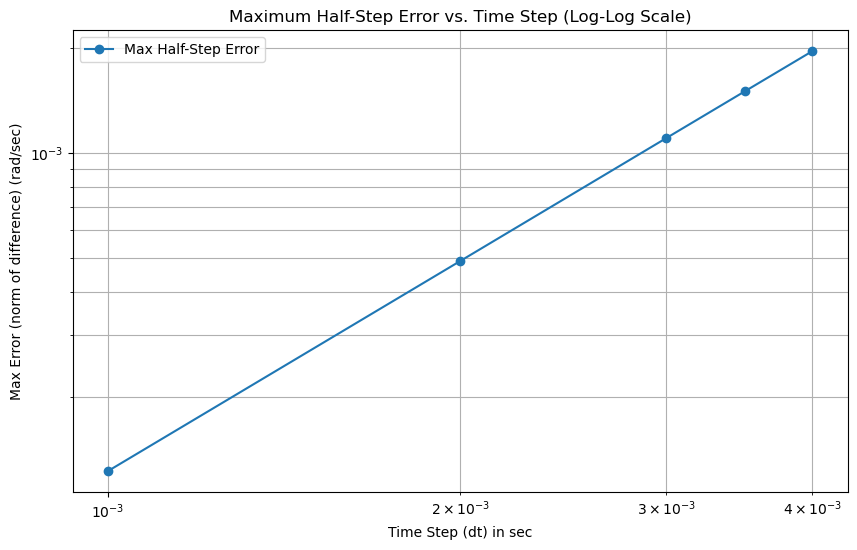

In [6]:
## Ans
start_time = 0.0 #sec
stop_time = 2 #sec
time_step = 0.001 #sec
max_half_step_error = []
time_step_list = [0.001, 0.002, 0.003, 0.0035, 0.004]
for time_step in time_step_list:
  N = int((stop_time- start_time)/time_step)+1
  t = np.linspace(start_time, stop_time,N,endpoint=True).reshape(-1,1)
 #<your code>

  # Generate omega(t) at sampled time points: Nx3 array
  omega = gen_omega_t(t, f1, f2, f3)

  # Pad omega by replicating boundary values to handle n=0 (no past) and n=N-1 (no future)
  # omega_pad[0] = omega[0], omega_pad[1..N] = omega[0..N-1], omega_pad[N+1] = omega[N-1]
  omega_pad = np.vstack([omega[0:1], omega, omega[-1:]])  # shape (N+2, 3)

  # Apply h_mid filter: f(t_n + ts/2) = h[0]*x(n+1) + h[1]*x(n) + h[2]*x(n-1)
  # h_mid = [3/8, 3/4, -1/8] for [future, current, past]
  omega_half_pred = (h_mid[0] * omega_pad[2:]   +   # future: omega[n+1]
                     h_mid[1] * omega_pad[1:-1] +   # current: omega[n]
                     h_mid[2] * omega_pad[:-2])      # past: omega[n-1]

  # Ground truth: evaluate omega analytically at half-step times t_n + ts/2
  t_half = t + time_step / 2.0
  omega_half_gt = gen_omega_t(t_half, f1, f2, f3)

  # Error: L2 norm of difference at each time step
  error = np.linalg.norm(omega_half_pred - omega_half_gt, axis=1)

#<end your code>
  max_half_step_error.append(np.max(error))
plt.figure(figsize=(10, 6))
plt.loglog(time_step_list, max_half_step_error, '-o', label='Max Half-Step Error')
plt.title('Maximum Half-Step Error vs. Time Step (Log-Log Scale)')
plt.xlabel('Time Step (dt) in sec')
plt.ylabel('Max Error (norm of difference) (rad/sec)')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()


**Observations:**

**Power-law relationship:** The log-log plot shows a straight line, which means the error follows a power-law: Error ≈ C · dt^k. Taking the log of both sides gives log(Error) = log(C) + k·log(dt), a line with slope k. The slope is approximately **k ≈ 2**, meaning the half-step interpolation error scales quadratically with the time step. This is expected — fitting a quadratic polynomial (3-tap Savitzky-Golay filter) yields a method with O(dt²) accuracy.

**Connection to signal frequency:** The signal ω(t) contains three cosines with frequencies 1 Hz, 2 Hz, and 4 Hz. The highest frequency component is **4 Hz** (period = 0.25 s). From the plot, to keep the max half-step error below ~0.1 rad/s, the time step must be kept below roughly **dt ≈ 2 ms**, corresponding to a sampling rate of **fs ≈ 500 Hz**. This is about 125× the highest signal frequency (4 Hz), illustrating that for accurate interpolation — as opposed to mere reconstruction — significant **oversampling** is required beyond the Nyquist rate (8 Hz).

**Key takeaway:** As dt increases toward the period of the highest-frequency component (0.25 s), the quadratic interpolation breaks down rapidly because the filter can no longer capture the signal's curvature within each interval. Keeping dt small (high sampling rate) is essential to make the half-step prediction accurate.

**Chat with TA ( do not delete this line)**

*You can ask the TA for help by replacing this sentence your query etc here and then clicking the button in the next cell*

In [ ]:
#@title Run this cell to get the button and then click it to get feedback from the TA about your answer and query/comment
ta.show_teaching_assist_button(session,AI_TA_URL, 3, notebook_id, institution_id, term_id, course_id)

---
**Q4: 10**

Consider the angular rate of rotation used in Q3, which has three sinusoids of frequencies of 1hz, 2hz and 4hz for the three axes.

Assume that the device starts at an initial pose of Identity.

We want to estimate the pose at time t=2s.

a) Complete the code for angular rate integration via rk4 and the quaternion integration

b) use it to

plot the error of the final orientation w.r.t ground truth by sweeping across different time steps  for integration, starting from a timestep of 1ms to 1s in increments of 1ms.

c) What is your observation in terms of what time steps to use?

In [7]:
##Ans


#a)

def integ_euler(w,ts):
  '''
  Euler integration of rates in each time step to get angle changes
  input:
  w: Nx3 numpy array of angular rates
  ts: time step
  output:
  d_theta: Nx3 numpy array of angle changes
  '''
  d_theta = np.zeros_like(w)
  d_theta = w*ts
  return d_theta

def integ_rk4(w,ts):
  '''
  RK4 integration of rates in each time step to get angle changes
  This turns out to be the same of Simpson's rule in this particular case
  input:
  w: Nx3 numpy array of angular rates
  ts: time step
  output:
  d_theta: Nx3 numpy array of angle changes
  '''
  d_theta = np.zeros_like(w)

  # RK4 (Simpson's rule) using consecutive samples
  # k1 = w[i], k4 = w[i+1], k2=k3 = midpoint (linear interpolation)
  k1 = w[:-1]
  k4 = w[1:]
  k2 = 0.5 * (k1 + k4)
  k3 = k2
  d_theta[:-1] = (ts / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
  d_theta[-1] = w[-1] * ts  # Euler for last step (no next sample)

  #<end your code>

  return d_theta

---
The following package conveniently implements the needed logic for manipulations using quaternions and rotation matrices:

Documentation of the functions is here:

https://quaternion.readthedocs.io/en/latest/quaternion/


In [8]:
# This package provides convenience functions to do quaternion math
!pip install numpy-quaternion
import quaternion as qtn

In [12]:

def QuatInt(q,w,ts,type='euler'):
  '''

  q: initial quaternion of type np.quaternion
  w: angular rate array N x 3
  ts: time step
  type: 'euler' or 'rk4'
  '''
  if type == 'euler':
    d_theta = integ_euler(w,ts)
  else: #rk4
    d_theta = integ_rk4(w,ts)

  #initalize an array for intermedial quats. useful later
  zero_rot = np.zeros((w.shape[0]+1,3),dtype=np.float64)
  q_arr = qtn.from_rotation_vector(zero_rot)
  q_arr[0] = q

  #convert angular changes to quaternion changes
  q_d_theta = qtn.from_rotation_vector(d_theta)

  #integrate to get final quaternion
  for i in range(d_theta.shape[0]):
    #<your code
    q = q * q_d_theta[i]  # rotate current orientation by incremental quaternion
    #End of your code
    q_arr[i+1] = q

  return q, q_arr

In [9]:
def sig(t,amp,freq,phase):
  '''Raw signal - a cosinusoid
  '''
  return amp*np.cos(2*np.pi*freq*t+phase)

def intsig(t,ts,amp,freq,phase):
  '''
  integral of cosinusoid for each time step
  '''
  return amp/(2*np.pi*freq)*(np.sin(2*np.pi*(t+ts)+phase)- np.sin(2*np.pi*t+phase))

vsig = np.vectorize(sig)
vintsig = np.vectorize(intsig)

def QuatInt_gt(q,t,ts,a_1, f_1, ph_1, a_2, f_2, ph_2, a_3, f_3, ph_3):
  '''
  ground truth based on analytical integration of angular rate
  q: initial quaternion of type np.quaternion
  ts: time step
  '''
  d_theta = np.hstack((intsig(t,ts,a_1, f_1, ph_1),
                       intsig(t,ts,a_2, f_2, ph_2),
                       intsig(t,ts,a_3, f_3, ph_3)
                      )
                      )
  #convert angular changes to quaternion changes
  q_d_theta = qtn.from_rotation_vector(d_theta)

  #integrate to get final quaternion
  for i in range(d_theta.shape[0]):
    #<your code>
    q = q * q_d_theta[i]  # rotate current orientation by incremental quaternion
    #End of your code

  return q

In [10]:
#ground truth quaternion
#analytical integration with 0.1ms time step

def get_q_gt(q, start_time, stop_time, time_step, a_1, f_1, ph_1, a_2, f_2, ph_2, a_3, f_3, ph_3):
  '''
  give the ground truth quaternion
  '''

  N = int((stop_time- start_time)/time_step)+1
  t = np.linspace(start_time, stop_time,N,endpoint=True).reshape(-1,1)
  q_gt = QuatInt_gt(q,t,time_step,a_1, f_1, ph_1, a_2, f_2, ph_2, a_3, f_3, ph_3)
  return q_gt

In [ ]:
#b)


start_time = 0.0 #sec
stop_time = 2.0 #sec
time_step = 0.0001 #sec #really small value to calculate the ground truth pose

#amplitude, frequency and phase of the three cosines for the three components of the angular rate
a_1,f_1,ph_1 = 1.0,1.0,0.0
a_2,f_2,ph_2 = 1.0,4.0,0.0
a_3,f_3,ph_3 = 1.0,2.0,0.0

#ground truth quaternion calculation
#initial orientation
q = np.quaternion(1.,0.,0.,0.)
q_gt = get_q_gt(q, start_time, stop_time, time_step, a_1, f_1, ph_1, a_2, f_2, ph_2, a_3, f_3, ph_3)

error_euler =[] #error of final orientation via euler integration w.r.t ground truth versus time step
error_rk4   =[] #error of final orientation via rk4 integration w.r.t ground truth versus time step

time_step_list = np.arange(0.001, 1.0, 0.001)
for time_step in time_step_list:
  N = int((stop_time- start_time)/time_step)+1
  t = np.linspace(start_time, stop_time,N,endpoint=True).reshape(-1,1)
  #sampled angular rates as a Nx3 array
  w = np.hstack((vsig(t,a_1, f_1, ph_1), vsig(t,a_2, f_2, ph_2),vsig(t,a_2, f_3, ph_3)))
  #<Your code here>

  # Integrate angular rates with Euler (RK1) and RK4
  q_init = np.quaternion(1., 0., 0., 0.)
  q_euler, _ = QuatInt(q_init, w, time_step, type='euler')
  q_rk4,   _ = QuatInt(q_init, w, time_step, type='rk4')

  # Angular error: norm of rotation vector of (q_gt^-1 * q_estimated)
  err_euler = np.linalg.norm(qtn.as_rotation_vector(q_gt.conjugate() * q_euler))
  err_rk4   = np.linalg.norm(qtn.as_rotation_vector(q_gt.conjugate() * q_rk4))

  error_euler.append(err_euler)
  error_rk4.append(err_rk4)

  #<End your code>

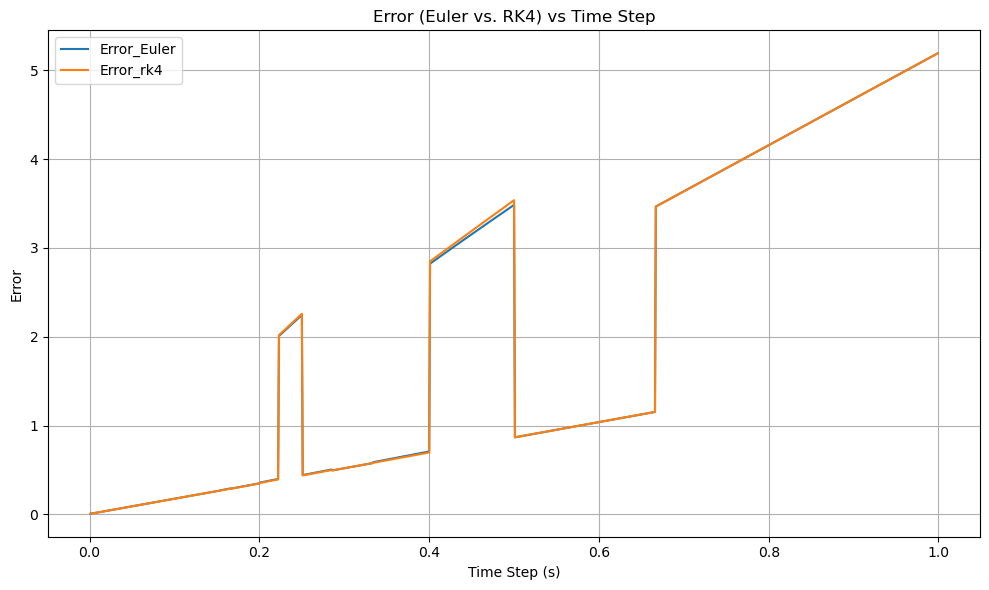

In [14]:
plt.figure(figsize=(10, 6))

plt.plot(time_step_list, error_euler, label='Error_Euler')
plt.plot(time_step_list, error_rk4, label='Error_rk4')
plt.title('Error (Euler vs. RK4) vs Time Step')
plt.xlabel('Time Step (s)')
plt.ylabel('Error')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


c)


**Observations on Error vs. Time Step (Euler vs. RK4):**

**Both errors grow with time step**, but at very different rates. On the plot, Euler (RK1) error grows roughly linearly with dt (slope ≈ 1 on a log-log scale), while RK4 error grows much more steeply for larger dt but remains orders of magnitude smaller for small dt (slope ≈ 4 on a log-log scale), consistent with their respective O(dt) and O(dt⁴) local truncation errors.

**Recommended time step:** To keep the orientation error small, dt should be well below the period of the highest-frequency angular rate component. Here the highest frequency is 4 Hz (period = 0.25 s), so a time step of **dt ≤ 10 ms (fs ≥ 100 Hz)** is a reasonable working point — at this rate RK4 achieves much lower error than Euler for the same computational budget.

**Why RK4 is better:** Euler uses only the angular rate at the start of each interval, making a constant-rate assumption over the step. RK4 evaluates slope estimates at the beginning, two midpoints, and the end, capturing the curvature of the rotation trajectory within each interval. This gives RK4 a fourth-order convergence advantage over Euler's first-order convergence, so for any given acceptable error threshold, RK4 allows a significantly larger time step — reducing the number of integration steps needed and saving computation.

**Aliasing at large time steps:** When dt grows beyond the Nyquist limit for the highest-frequency component (4 Hz), aliasing sets in. The Nyquist theorem requires sampling at more than twice the highest frequency, i.e., fs > 8 Hz, which means dt < 1/8 s = 0.125 s. For dt > 0.125 s, the sampler can no longer correctly resolve the 4 Hz sinusoid — the sampled values appear to belong to a lower (aliased) frequency. On the error plot this manifests as erratic, non-monotonic jumps in error for large time steps, rather than the smooth power-law growth seen at smaller dt. This is aliasing in action: once the sampling rate drops below Nyquist, the integration receives a fundamentally incorrect view of the angular rate signal, and no choice of integrator (Euler or RK4) can correct for it.

**Coning error:** Our strapdown integration follows two steps — (1) integrate ω(t) over [t_k, t_{k+1}] to obtain a rotation vector Δθ, then (2) update orientation via q_{k+1} = q_k · q(Δθ). This implicitly assumes the rotation axis is **fixed** throughout each time step. In reality, because ω(t) is continuously changing direction, the true rotation axis is also rotating — the body is undergoing a **coning motion** (tip of the angular rate vector traces a cone). The mismatch between the assumed fixed-axis rotation and the true coning motion introduces an error called **coning error**, which accumulates over time and is proportional to the cone angle and step size. Crucially, coning error is a **geometric error** in how rotations are composed, not just a numerical integration error — so even a perfect high-order integrator like RK4 cannot eliminate it. This is a fundamental reason why high IMU sampling rates (typically 100 Hz–1 kHz in practice) are essential: smaller dt means smaller cone angles per step, directly suppressing coning error.

**Chat with TA**

*You can ask the TA for help by replacing this sentence your query etc here and then clicking the button in the next cell*

In [ ]:
#@title Run this cell to get the button and then click it to get feedback from the TA about your answer and query/comment
ta.show_teaching_assist_button(session,AI_TA_URL, 4, notebook_id, institution_id, term_id, course_id)

---
**The Pose Estimation Problem**

The key problem is to estimate $T_k \approx \hat{T_k}$, for all k,  as accurately as possible, given the set of measurements $\{u,v,w...\}_k$ from a set of sensors (either on the body or in the world).

Typically there are two modes:

- Causal or filtering: Here only current and past sensor values are used to estimate the current pose.

- Smoothing: Here all the sensors values are used to estimate the current and past poses.

If we know the motion dynamics, we can also predict the future poses of the body give the current and past pose states.

---
**IMU Sensor and Equations**


The Inertial Measurement Unit (IMU) typically has 3 independent sensors within it:

- 3-axis accelerometer to measure body's linear acceleration in the three axes of the body frame

- 3 axis gyroscope to measure body's angular rate of rotation across the three axes of the body

- 3 axis magnetometer to measure magnetic moment in the body frame.

Many times only accelerometer and gyro are used.

Let $\omega^T(t), \omega(t) \in ℝ^3$ be the true and measured angular velocity of the body - as observed in the body frame.

Then $\dot{\theta}(t)=\omega(t)=\omega^T(t)+b_g(t)+n_{gr}(t)$

with
$b_g(t)$ Gyro's bias drift over time, which should also be estimated.

$n_{gr}(t)$: Gyro's random measurement noise with zero mean and variance $\sigma_{gr}^2$ given by the manufacturer (or estimated/characterized separately in the lab)

With sampling rate at $f_s=\frac{1}{T_s}$, the discrete time measurements are:

Angular velocity (measured in body frame):

$\omega_k = \omega^T_k + b_{g_k} +  n_{gr_k}$

Acceleration (measured in body frame):

$a_k = a^T_k$$\ + b_{a_k} + n_{ar_k}$

$n_{gr_k}\ \ \tilde \ \ \ N(0,\sigma^2_{gr}f_sI_{3\times3})= N(0,\Sigma_{gr})$

$n_{ar_k}\ \ \tilde \ \ \ N(0,\sigma^2_{ar}f_sI_{3\times3}) = N(0,\Sigma_{ar})$




Using these measurements, we can estimate the pose state:

$T_k = \begin{bmatrix} R_k & p_k \\ 0 & 1 \end{bmatrix}$

as well as the two biases $b_{g_k}, b_{a_k}$ and the velocities $v_k$

*Orientation estimation*

$R_{k+1} = R_k \oplus ((\omega_k - b_{g_k}) T_s)$ (borrowing notation from Sola et. al., Micro-Lie Theory )

*Velocity Estimation*

$v_{k+1} = v_k + R_k(a_k-b_{a_k})T_s -\bf{g}$$T_s$

*Position Estimation*

$p_{k+1} = p_k + v_k T_s - \frac{1}{2}\bf{g}$$ T_s^2 + \frac{1}{2}R_k(a_k-b_{g_k}) T_s^2$

and

A often used model for bias drift is  a random walk

$b_{g_{k+1}} = b_{g_k} + n_{gb_k}$

$b_{a_{k+1}} = b_{a_k} + n_{ab_k}$

With

$n_{gb_k}\ \ \tilde \ \ \ N(0,\sigma^2_{gb}f_sI_{3\times3}) = N(0,\Sigma_{gb})$

$n_{ab_k}\ \ \tilde \ \ \ N(0,\sigma^2_{ab}f_sI_{3\times3})= N(0,\Sigma_{ab})$

---
**Noise Spectral Density**

$n(t)$ is a random process (collection of random variables indexed by a continuous variable: t). Assume zero mean.

Auto-correlation: $R(t_1, t_1+\tau) = En(t_1)n(t_1+\tau)$

For a wide sense stationary process, $R(t_1, t_1+\tau) = R(\tau)$, i.e the autocorrelation is independant of $t_1$ and only depends on the time difference $\tau$.

$S(f) = FFT(R(\tau)) = \int e^{-i2\pi f\tau}R(\tau)d\tau$ (Fourier Transform)

and $R(\tau) = IFFT(S(f)) = \int e^{2\pi f\tau} S(f) df$ (Inverse Fourier Transform)

Since  $\int S(f) df = R(0) = En^2(t)$ is the power of the signal, S(f) is the power spectral density.

Thus the specification of the noise is given as $\sigma$ $(physical units/\sqrt{Hz})$

And the noise process, n(t), be zero mean with variance of $\sigma^2$. Further we will assume it to be Normally distributed.

Let the noise process be sampled in time with a sampling rate of $f_s$ (and sample spacing of $1/f_s$), to give noise samples $n(k)=n(k/f_s)$.

Usually we have a anti-aliasing filter (low pass filter_ of bandwidth $f_s/2$ before sampling - which restricts the total noise power after sampling to be $\sigma^2 f_s$

Hence each $n_k \approx N(0,\sigma^2f_s)$

**Angular position - Integral of Angular Velocity**

The commonly available rate gyroscopes (as part of the Intertial Measurement Units), measure angular rates in each orthogonal axis to give $\omega^m \in ℝ^3$

For each of the three axis a measurement model for the angular velocity is given as:

$\dot{\theta}^m(t)= \omega^m(t)=\omega(t)+n_{gr}(t)+b_{g}(t)$

Where:

$\omega(t)$ is the true angular velocity

$n_{gr}(t)$ is angular rate random noise modeled to have white spectral density

$b_{g}(t)$ is the randomness of the angular rate bias, due to slow drift of the bias and is modeled as a random walk of a white noise source:

$b_{g}(t) = \int_{-∞}^t n_{gb}(t) dt $

The measured anglular position is then obtained as:

$\theta^m(t) = \theta(t_0)+\int_{t_0}^{t} \omega^m(t)dt$

Whereas the true angular position (uncorrupted by measurement noise) is:

$\theta(t) = \theta(t_0)+\int_{t_0}^{t} \omega(t)dt$

A typical sensor measures the signal at discrete time instances, with a sampling rate of $f_s$ Hz (or samples per second).

Usually, an anti-aliasing filter of bandwith $< \frac{f_s}{2}$ is used before the analog to digital converter in the electronics front end, to avoid aliasing (Nyquist theorem).

Thus for the $k^{th}$ time sample, the measured angular rate is:

$\omega^m_k = \omega_k + n_{gr_k}+b_{g_k}$

$b_{g_k} = b_{g_{k-1}} + n_{gb_k}$

Here $n_{gr_k}$ and $n_{gb_k}$ are the sampled versions of the respective continuous noise process.


The noise variances for the sampled case is obtained from the respective power spectral density of the continuous version as:

$\sigma_{gr}^s = \sigma_{gr}\sqrt{f_s}$

$\sigma_{gb}^s = \sigma_{gb}\sqrt{f_s}$

---
**Specification of Angular Rate Random Noise**

Randomness due to white noise in rate measurement (when sampled at $f_s = \frac{1}{{\Delta}t})$:

$\theta_n(t_j-t_i) = \int_{t_i}^{t_j} n_{gr}(t) dt \approx \Sigma_{k=1}^N n_{gr_k} {\Delta}t$

is a random variable with zero mean and normal pdf with variance calculated as:

$\sigma^2_{\theta_n} \approx N {\Delta}t^2Var(n_{gr_k}) = t_{ij}\sigma_{gr}^{2}$


Here $t_j-t_i = t_{ij} = N\Delta t$


Thus noise (std. dev) grows as $\sqrt{t}$ and is called as a random walk.

This noise is specified either as a:

Angular Random Walk (ARW) as $\sigma_\theta(1)$: units of $(°/\sqrt{hr})$

or

Angular Rate Noise Density (ARND) $\sigma_{gr}$: units $°/hr/\sqrt{hz}$ or $°/s/\sqrt{hz}$

Note that you can convert between the two above as:

$ARW(°/\sqrt{hr})=\frac{1}{60}ARND(°/hr/\sqrt{hz}) = 60*ARND(°/s/sqrt{hz})$

for e.g.
BOSCH IMU 360 has ARND of 0.007$\frac{deg}{s\sqrt{hz}}$. Hence ARW = $60*0.007=0.42 \frac{deg}{\sqrt{hr}}$ This means that one hour, the std. dev of angle uncertainty is 0.42° and after 4hrs, it is 0.84° and so on.

---
**Bias (in) Stability**

The bias slowly drifts over time. It is modeled as a random walk of a gaussian noise with spectral density $\sigma^2_{gb}$ specified in units of ($(\frac{°}{{s^{3/2}}{\sqrt{Hz}}}$) or as bias instability in units of $\frac{°}{hr}$ which represents a standard deviation of angle rate bias over a period of $\tau$ (this time depends on the device).

If $b_g(t_j)$ is the bias at time $t_j$ then

$b_g(t_i) = b_g(t_j) + \dot{\theta_{gb}}(t_i-t_j)$

where $\dot{\theta_{gb}}(t_i-t_j) \approx \Sigma_{k=1}^N n_{gb_k}{\Delta}t $

Hence $Var(\dot{\theta_{gb}}(t)) = \sigma_{\dot\theta_{gb}}(t)^2 \approx N {\Delta}t^2\sigma_{gb}^2f_s=\sigma_{gb}^2t$.

Manufacturers will usually spec  $\sigma_{\theta_{gb}}$ in $°/Hr$ - for a certain correlation time, $\tau$. Which means, the std. deviation for any other time, $t \gt \tau$, is: $\sigma_{\theta_{gb}}*\sqrt{t/\tau}$

For times $t \lt \tau$ we can model  the bias to be a constant.

For consumer grade IMU like BOSCH IMU 360, the bias instability will be around $10°/hr$ which means if we examine the angle after 1 second, we can expect it to be off on an average by $10*1/60 = 0.16°$


---

We will next use the the "Versatile Quaternion Filter - vqf" from Liadig

In [15]:
%%capture
!pip install vqf
from vqf import PyVQF

---
**Datasets**

https://github.com/dlaidig/broad has datasets of IMU measurements along with  ground truth. The ground truth is recorded using a optical motion tracking system.

Datasets under various conditions have been collected.

Read the associated paper for a more detailed description of the dataset.

In [16]:
%%capture
#down load one dataset from BROAD
!wget https://github.com/dlaidig/broad/raw/refs/heads/main/data_mat/01_undisturbed_slow_rotation_A.mat

In [17]:
#load the data and see what is in there
data = spio.loadmat("01_undisturbed_slow_rotation_A.mat")
print(data.keys())
gyr = data['imu_gyr'] #3 axes rate gyro measurements
acc = data['imu_acc'] #3 axes accelerometer measurements
mag = data['imu_mag'] #3 axes magnetometer measurements
opt_quat= qtn.as_quat_array(data['opt_quat'])
optInv = opt_quat.conjugate() #get the inverse of ground truth ready to calculate error
fs = data['sampling_rate'][0,0]
dt = 1.0/fs
print(f"Sampling rate = {fs} Hz : Sampling time step = {dt} s")
print(f"Number of samples = {len(gyr)} for duration {len(gyr)*dt}s")

FileNotFoundError: [Errno 2] No such file or directory: '01_undisturbed_slow_rotation_A.mat'

---
**Q5: 10**


Create a set of plots showing the gyroscope, accelerometer, and magnetometer data over the full duration of the recording.

You can zoom into various portions of the plot to get a better view of the data - by playing around with the start_index and index_window in the setup portion of the code below.

Based on your plots, answer the following:

a) Describe the different phases of motion you observe (e.g., periods of rest, periods of movement). Identify the approximate start and end times for these phases.

b) During a period of rest, what is the approximate reading of the accelerometer? What can you infer about the IMU's orientation with respect to gravity?

c) During the period of movement, what is the characteristic shape of the accelerometer and magnetometer data? What can you infer about the type of motion occurring?

d) What do you observe about the data at the exact moments when the motion starts and stops?"

NameError: name 'gyr' is not defined

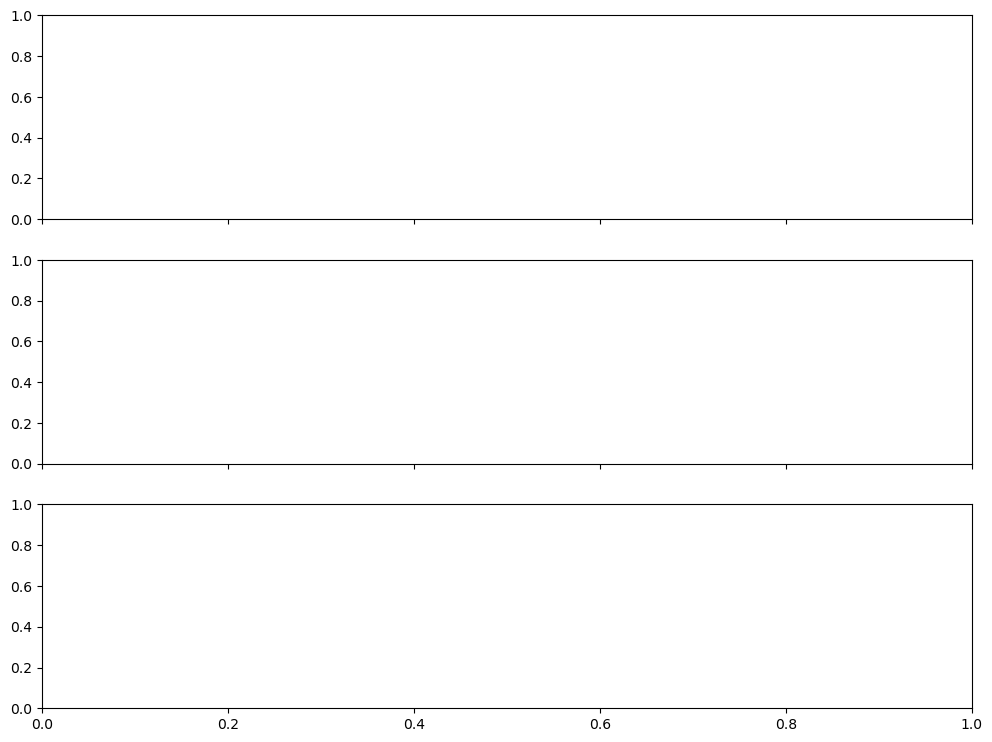

In [18]:
##Ans

start_index = 1 #in sample index
index_window = 56000 #window of samples to plot
time_segment = np.arange(start_index, start_index + index_window) * dt

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

#<Your code here>

# --- Gyroscope ---
axes[0].plot(time_segment, gyr[start_index:start_index + index_window])
axes[0].set_title('Gyroscope (Angular Rate)')
axes[0].set_ylabel('Angular Rate (rad/s)')
axes[0].legend(['X', 'Y', 'Z'], loc='upper right')
axes[0].grid(True)

# --- Accelerometer ---
axes[1].plot(time_segment, acc[start_index:start_index + index_window])
axes[1].set_title('Accelerometer (Specific Force)')
axes[1].set_ylabel('Acceleration (m/s²)')
axes[1].legend(['X', 'Y', 'Z'], loc='upper right')
axes[1].grid(True)

# --- Magnetometer ---
axes[2].plot(time_segment, mag[start_index:start_index + index_window])
axes[2].set_title('Magnetometer (Magnetic Field)')
axes[2].set_ylabel('Magnetic Field (µT)')
axes[2].set_xlabel('Time (s)')
axes[2].legend(['X', 'Y', 'Z'], loc='upper right')
axes[2].grid(True)

plt.suptitle('IMU Sensor Data', fontsize=14)
plt.tight_layout()
plt.show()



**a) Phases of motion:**
The dataset is titled 'undisturbed slow rotation', and the sensor data reflects this clearly. There are two observable phases:
- **Rest phase** (~t = 0–5 s and at the end): The gyroscope readings are near zero on all three axes, and the accelerometer shows a constant bias offset dominated by gravity (~9.8 m/s²). The magnetometer is also approximately constant.
- **Motion phase** (middle portion): The gyroscope shows smooth, low-amplitude sinusoidal-like oscillations as the device undergoes slow rotation. The accelerometer and magnetometer also show gradual, smooth changes as the orientation with respect to gravity and the Earth's magnetic field changes.

**b) Accelerometer during rest:**
During rest, one axis of the accelerometer reads approximately **±9.8 m/s²** (1g) while the other two read close to 0. This indicates that gravity is aligned almost entirely with one body-frame axis, meaning the IMU is oriented so that axis points vertically. The specific axis and sign reveal the IMU's orientation relative to the gravity vector.

**c) Accelerometer and magnetometer during motion:**
During slow rotation, the accelerometer readings vary smoothly — the gravity component redistributes across all three axes as the orientation changes, tracing sinusoidal-like curves. Similarly, the magnetometer components vary smoothly as the projection of Earth's magnetic field onto each body axis changes with orientation. This smooth, coupled variation across axes is characteristic of a slow, undisturbed rotation.

**d) Behaviour at motion onset and end:**
At the exact moment motion starts and stops, there are brief transient spikes or step-changes visible in the gyroscope signal — the angular rate jumps from zero to a small non-zero value at the start and returns to zero at the end. The accelerometer may also show a slight transient at these instants due to the impulsive angular acceleration, before settling into the smooth rotation-induced gravity projection pattern.

**Check with TA (do not delete this line)**

*You can ask the TA for help by replacing this sentence your query etc here and then clicking the button in the next cell*

In [ ]:
#@title Run this cell to get the button and then click it to get feedback from the TA about your answer and query/comment
ta.show_teaching_assist_button(session,AI_TA_URL, 5, notebook_id, institution_id, term_id, course_id)

---
**Q6: 10**


a)
Using scipy.signal.butter, design a 2nd-order digital Butterworth low-pass filter with a cutoff frequency of fc_gyr, fc_acc, fc_mag. Use the sampling rate fs of the BROAD dataset.  (See: https://schaumont.dyn.wpi.edu/ece4703b21/lecture3.html and scipy documents)


A plot of the acc filter's frequency response (magnitude in dB vs. frequency in Hz) using a cut off of 0.1 Hz.


b) Apply the filter on the IMU data and plot the raw and filtered values. Experiment with different cut-off frequency values for the three and explain which values you would finally use.

c) Explain and implement the logic to generate  true_rest_signal which  is one when the body is in rest and 0 when it is in motion.





##Ans (do not delete this line)

a) We will first implement the filter and get its response

In [ ]:
class lpf:
  """Low Pass Filter class implementing a 2nd order Butterworth filter.

  Attributes:
    b (np.ndarray): Numerator (feedforward) coefficients of the filter.
    a (np.ndarray): Denominator (feedback) coefficients of the filter.
    s (np.ndarray): Internal state of the filter, (N, 2) where N is the number of channels.
  """
  def __init__(self, fc=1/10., fs=fs, ord=2):
    """Initializes the lpf with filter coefficients.

    Args:
      fc (float): Cutoff frequency in Hz.
      fs (float): Sampling frequency in Hz.
      ord (int): Order of the Butterworth filter.
    """
    self.b, self.a = signal.butter(ord, fc, btype='lowpass', fs=fs, output='ba')
    self.s = None # State will be initialized by init_state
    self.fc = fc
    self.fs = fs
    self.ord = ord

  def init_state(self, x_initial):
    """Initializes the internal state of the filter.

    Args:
      x_initial (np.ndarray): Initial input vector (N,) for N channels.
    """
    if self.b is None or self.a is None:
      raise ValueError("Filter coefficients b and a must be set before initializing state.")

    #<Your code here>
    # lfilter_zi returns the steady-state zi for unit step input; scale by x_initial
    zi = signal.lfilter_zi(self.b, self.a)   # shape: (filter_order,)
    self.s = np.outer(zi, x_initial)          # shape: (filter_order, N_channels)
    #end your code

  def filter_step(self, x):
    """Applies one step of the filter to the input signal.

    Args:
      x (np.ndarray): Current input vector (N,) for N channels.

    Returns:
      np.ndarray: Filtered output vector (N,).
    """
    if self.s is None:
      raise ValueError("Filter state 's' must be initialized before filtering.")

    #<your code here>
    y = np.zeros(len(x), dtype=float)
    for ch in range(len(x)):
      # lfilter with zi returns (output, updated_state) for one sample
      out, self.s[:, ch] = signal.lfilter(self.b, self.a, [x[ch]], zi=self.s[:, ch])
      y[ch] = out[0]
    #end your code
    return y

  def plot_freq_response(self):
    """Plots the frequency response of a filter.
    """
    w, h = signal.freqz(self.b, self.a, worN=8000, fs=self.fs)

    plt.figure(figsize=(10, 6))
    plt.semilogx(w, 20 * np.log10(abs(h)))
    plt.title(f'Filter Frequency Response (Order={self.ord}, Cutoff={self.fc} Hz, Fs={self.fs} Hz)')
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Amplitude [dB]')
    plt.margins(0, 0.1)
    plt.grid(which="both", axis="both")
    plt.axvline(self.fc, color='green', linestyle='--', label=f'Cutoff Freq ({self.fc} Hz)')
    plt.legend()
    plt.show()

In [ ]:
#Test the filter

#filter cut off
fc_gyr=1 #Hz
fc_acc=0.1 #Hz
fc_mag=0.1 #Hz

#filter order
ord=2

#acc filter and its initialization
filt_a = lpf(fc=fc_acc, fs=fs, ord=ord)
filt_a.init_state(acc[0])

#gyr filter and its initialization
filt_g = lpf(fc=fc_gyr, fs=fs, ord=ord)
filt_g.init_state(gyr[0])

#mag filter and its initialization
filt_m = lpf(fc=fc_mag, fs=fs, ord=ord)
filt_m.init_state(mag[0])

# Plot the frequency response of the accel filter (others are same)
filt_a.plot_freq_response()


b)

**Chosen cut-off frequencies and reasoning:**

- **Gyroscope — fc_gyr = 1 Hz:** The true angular rate signal during slow rotation is below 1 Hz. High-frequency noise from the MEMS gyroscope (vibration, quantisation) sits well above 1 Hz, so a 1 Hz cut-off cleanly separates signal from noise without distorting the slow rotation.

- **Accelerometer — fc_acc = 0.1 Hz:** When the body is at rest the accelerometer measures only gravity (a DC component). During slow rotation the projection of gravity onto each body axis changes only at the rotation frequency (≪ 1 Hz). A 0.1 Hz cut-off extracts this slowly-varying gravity vector while rejecting higher-frequency vibration and dynamic acceleration spikes.

- **Magnetometer — fc_mag = 0.1 Hz:** The Earth's magnetic field is essentially DC. Its projection onto the body axes changes only as slowly as the device rotates. A 0.1 Hz cut-off therefore retains the heading information while suppressing electrical and environmental magnetic noise.

**Raw vs. filtered:** The filtered signals are visibly smoother with high-frequency ripple removed. The filtered accelerometer and magnetometer traces closely track the mean of the raw signal, confirming that the low-frequency content (gravity / Earth field) is preserved. The filtered gyroscope retains the slow rotation signature while the small noise fluctuations visible in the raw data are suppressed.

In [ ]:

#We will now apply the three filters on the three signals

filt_g.init_state(gyr[0])
filt_a.init_state(acc[0])
filt_m.init_state(mag[0])

# Initialize arrays to store full filtered signals
gyr_flt = np.zeros_like(gyr)
acc_flt = np.zeros_like(acc)
mag_flt = np.zeros_like(mag)
for i in range(len(gyr)):
  gyr_flt[i] = filt_g.filter_step(gyr[i])
  acc_flt[i] = filt_a.filter_step(acc[i])
  mag_flt[i] = filt_m.filter_step(mag[i])

In [19]:
start_time = 0 #s
time_window = 2 #s

start_index = int(start_time*fs) #in sample index
index_window = int(time_window*fs) #window of samples to plot
time_segment = np.arange(start_index, start_index + index_window) * dt

fig, axes = plt.subplots(3, 2, figsize=(15, 9), sharex=True) # 3 rows, 2 columns

# Row 1: Gyroscope data (Raw and Filtered)
axes[0, 0].plot(time_segment, gyr[start_index:start_index + index_window])
axes[0, 0].set_title(f'Raw Gyroscope Data')
axes[0, 0].set_ylabel('Angular Rate (rad/s)')
axes[0, 0].legend(['X', 'Y', 'Z'], loc='upper right')
axes[0, 0].grid(True)

axes[0, 1].plot(time_segment, gyr_flt[start_index:start_index + index_window])
axes[0, 1].set_title(f'Filtered Gyroscope Data')
axes[0, 1].legend(['X', 'Y', 'Z'], loc='upper right')
axes[0, 1].grid(True)

# Row 2: Accelerometer data (Raw and Filtered)
axes[1, 0].plot(time_segment, acc[start_index:start_index + index_window])
axes[1, 0].set_title(f'Raw Accelerometer Data')
axes[1, 0].set_ylabel('Acceleration (m/s^2)')
axes[1, 0].legend(['X', 'Y', 'Z'], loc='upper right')
axes[1, 0].grid(True)

axes[1, 1].plot(time_segment, acc_flt[start_index:start_index + index_window])
axes[1, 1].set_title(f'Filtered Accelerometer Data')
axes[1, 1].legend(['X', 'Y', 'Z'], loc='upper right')
axes[1, 1].grid(True)

# Row 3: Magnetometer data (Raw and Filtered)
axes[2, 0].plot(time_segment, mag[start_index:start_index + index_window])
axes[2, 0].set_title(f'Raw Magnetometer Data')
axes[2, 0].set_ylabel('Magnetic Field (uT)')
axes[2, 0].set_xlabel('Time (s)')
axes[2, 0].legend(['X', 'Y', 'Z'], loc='upper right')
axes[2, 0].grid(True)

axes[2, 1].plot(time_segment, mag_flt[start_index:start_index + index_window])
axes[2, 1].set_title(f'Filtered Magnetometer Data')
axes[2, 1].set_xlabel('Time (s)')
axes[2, 1].legend(['X', 'Y', 'Z'], loc='upper right')
axes[2, 1].grid(True)

plt.tight_layout()
plt.show()

NameError: name 'fs' is not defined

c)

**Logic for `true_rest_signal`:**

When the body is at rest, the accelerometer measures only gravity, so its magnitude is constant at approximately g ≈ 9.81 m/s². When the body moves, dynamic acceleration adds to gravity and the magnitude deviates from g.

**Steps:**
1. Compute `acc_diff` = |‖acc_flt‖ − g|, the per-sample deviation of the filtered accelerometer magnitude from 1g. This is near zero during rest and positive during motion.
2. Threshold `acc_diff` with a small value (e.g. 0.3 m/s²) to get a binary `rest_signal` (1 = rest, 0 = motion).
3. Apply a median filter over a ~1-second window to obtain `true_rest_signal`, which removes brief spurious 0→1 or 1→0 transitions caused by noise, giving a clean rest/motion indicator.

In [ ]:

#<your code>

from scipy.signal import medfilt

# Deviation of filtered accelerometer magnitude from gravity (9.81 m/s^2)
# Near zero at rest, positive during motion
g = 9.81  # m/s^2
acc_diff = np.abs(np.linalg.norm(acc_flt, axis=1) - g)  # shape (N,)

# Binary rest signal: 1 = at rest (small deviation from g), 0 = motion
threshold = 0.3  # m/s^2
rest_signal = (acc_diff < threshold).astype(float)

# True rest signal: median filter (~1 s window) to remove brief spurious transitions
kernel = int(fs) | 1  # ensure odd kernel length, ~1 second
true_rest_signal = (medfilt(rest_signal, kernel_size=kernel) > 0.5).astype(float)

#end your code

# Plot the gyroscope magnitude and the rest signal
time_full = np.arange(0, len(gyr)) * dt


start_time = 0 #s
time_window = 2 #s

start_index = int(start_time*fs) #in sample index
index_window = int(time_window*fs) #window of samples to plot
time_segment = np.arange(start_index, start_index + index_window) * dt

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True) # 3 rows, 2 columns
axes[0].plot(time_segment, acc_diff[start_index:start_index + index_window])
axes[0].set_title(f'Filtered accelerometer Data')
axes[0].set_ylabel('Acceleration (m/s^2)')
axes[0].set_xlabel('Time (s)')
axes[0].grid(True)

axes[1].plot(time_segment, rest_signal[start_index:start_index + index_window], label='Initial Rest Signal')
axes[1].plot(time_segment, true_rest_signal[start_index:start_index + index_window], label='True Rest Signal (filtered)', linestyle='--')
axes[1].set_title(f'Rest signal')
axes[1].set_ylabel('Rest/Motion')
axes[1].set_xlabel('Time (s)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

**Chat with TA (do not delete)**

*You can ask the TA for help by replacing this sentence your query etc here and then clicking the button in the next cell*

In [ ]:
#@title Run this cell to get the button and then click it to get feedback from the TA about your answer and query/comment
ta.show_teaching_assist_button(session,AI_TA_URL, 6, notebook_id, institution_id, term_id, course_id)

---
**Q7: 10**

Write a loop to do strapdown integration for the orientation by integrating the gyroscope measurements (gyr).

a)

Initialize your orientation quaternion with the first value from the ground truth (opt_quat[0]).

Inside the same loop, use the PyVQF library to estimate the orientation using inclination+heading correction and bias estimation for one filter and only inclination+heading correction without bias estimation for the second filte.


Error Analysis: For each time step, calculate the angular error (in radians) of all three estimates (error_strapdown, error_incl_head_correction_no_bias_estimation, error_incl_head_correction_with_bias_estimation) with respect to the ground truth (opt_quat) and plot the results

c)

Explain the results. Why does the strapdown integrator's error grow over time? Why is the filter with bias estimation more accurate than the one without?

In [ ]:
##Ans

#a)

#Error of simple strapdown integrator with OPT
error_no_corr = np.zeros(optInv.shape[0])

#Error of quat of VQF with heading,inclination corr and bias estimation
error_am_corr_with_bias_est = np.zeros(optInv.shape[0])

#Error of quat of VQF with headin,inclination corr but no bias estimation
error_am_corr_no_bias_est = np.zeros(optInv.shape[0])


#setup the time indices in seconds
t = np.linspace(0,len(gyr)*dt,len(gyr),False)

#<your code>

# --- Initialize strapdown quaternion with ground truth first sample ---
q_sd = opt_quat[0]

# --- PyVQF filter 1: inclination + heading correction WITH bias estimation (default) ---
vqf_with_bias = PyVQF(dt)

# --- PyVQF filter 2: inclination + heading correction WITHOUT bias estimation ---
vqf_no_bias = PyVQF(dt, restBiasEstEnabled=False, motionBiasEstEnabled=False)

for i in range(len(gyr)):
  # Strapdown: integrate gyro measurement over one time step
  dw = gyr[i] * dt                              # small-angle rotation vector
  q_sd = q_sd * qtn.from_rotation_vector(dw)    # apply incremental rotation
  error_no_corr[i] = np.linalg.norm(
      qtn.as_rotation_vector(optInv[i] * q_sd)) # angular error w.r.t. ground truth

  # VQF updates: feed gyro + acc + mag (9D: inclination + heading correction)
  vqf_with_bias.update(gyr[i], acc[i], mag[i])
  vqf_no_bias.update(gyr[i], acc[i], mag[i])

  # Extract orientation quaternions (returned as [w, x, y, z])
  q_bias    = qtn.from_float_array(vqf_with_bias.getQuat9D())
  q_no_bias = qtn.from_float_array(vqf_no_bias.getQuat9D())

  error_am_corr_with_bias_est[i] = np.linalg.norm(
      qtn.as_rotation_vector(optInv[i] * q_bias))
  error_am_corr_no_bias_est[i]   = np.linalg.norm(
      qtn.as_rotation_vector(optInv[i] * q_no_bias))



In [ ]:
#your code to plot

plt.figure(figsize=(12, 5))
plt.plot(t, np.degrees(error_no_corr),
         label='Strapdown (gyro only)', alpha=0.85)
plt.plot(t, np.degrees(error_am_corr_no_bias_est),
         label='VQF: incl+heading, no bias est.', alpha=0.85)
plt.plot(t, np.degrees(error_am_corr_with_bias_est),
         label='VQF: incl+heading + bias est.', alpha=0.85)
plt.xlabel('Time (s)')
plt.ylabel('Angular Error (degrees)')
plt.title('Orientation Error vs. Ground Truth (Q7)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



**Observations:**

**Strapdown integrator (gyro only):** The error grows monotonically over time. This is because the gyroscope measurement contains a slowly-drifting bias (b_g(t) in the sensor model) and white noise n_gr(t). Integrating the bias directly accumulates as a ramp in orientation error (O(t)), while the white noise contributes an angular random walk (O(√t)). With no correction mechanism, these errors grow unbounded — a fundamental limitation of pure dead-reckoning strapdown integration.

**VQF without bias estimation:** The error is significantly lower and remains roughly bounded compared to the strapdown integrator. The accelerometer provides a gravity reference that corrects inclination (roll/pitch) drift, and the magnetometer corrects heading (yaw) drift. However, without bias estimation the gyroscope bias still causes a slow residual drift between correction updates, visible as a small but non-zero steady-state error.

**VQF with bias estimation:** This achieves the lowest error. During detected rest periods, the filter observes that the gyroscope should read zero and uses the difference to estimate and subtract the bias. During motion, the accelerometer and magnetometer corrections keep the orientation anchored. The combination of bias estimation and external corrections breaks the error accumulation cycle, giving a substantially more accurate and stable orientation estimate over long durations.

**Key takeaway:** Gyro bias is the dominant error source in strapdown integration. Fusing with accelerometer and magnetometer corrections (inclination + heading) bounds the error, and additionally estimating and removing the bias reduces it further — motivating the sensor fusion approach used in all practical IMU algorithms.

**Chat with TA**

*You can ask the TA for help by replacing this sentence your query etc here and then clicking the button in the next cell*

In [ ]:
#@title Run this cell to get the button and then click it to get feedback from the TA about your answer and query/comment
ta.show_teaching_assist_button(session,AI_TA_URL, 7, notebook_id, institution_id, term_id, course_id)

**Q8: 20**

Implement VQF Algorithm of Laidig with  bias estimation based on rest detection.

You can use this as a reference: https://github.com/dlaidig/vqf/blob/main/vqf/pyvqf.py

We will use the downloaded IMU data as well as the ground truth in  "01_undisturbed_slow_rotation_A.mat", from the BROAD dataset (this has been done a few cells earlier).

Plot the error of orientation from
your implementation with only inclination correction and bias estimation, your implementation with inclination+heading correctiona and bias estimation
and compare with vqf with bias

In [ ]:
##Ans

q_3D = np.zeros_like(opt_quat) #strapdown integration
q_inc_corr = np.zeros_like(opt_quat) #inclination correction quat
q_6D = np.zeros_like(opt_quat) #6D quat
q_head_corr = np.zeros_like(opt_quat) #heading correction quat
q_9D = np.zeros_like(opt_quat) #9D quat

#Initialize all three quats to optical tracker ground truth
q_3D[0] = opt_quat[0]
q_6D[0] = opt_quat[0]
q_9D[0] = opt_quat[0]

#initialize to identity the two correction quats
q_inc_corr[0] = qtn.from_rotation_vector(np.zeros(3)) #identity quat
q_head_corr[0] = qtn.from_rotation_vector(np.zeros(3)) #identity quat
delta_head = np.zeros(len(gyr),dtype=np.float64) #heading correction in yaw angle (CCW)
delta_head[0] = 0
ang = np.zeros(len(gyr),dtype=np.float64) #instantaneous hEADING
ang[0] = 0

# Vectors to keep track of error for plotting
err_3D = np.zeros(len(gyr),np.float64)
err_6D = np.zeros(len(gyr),np.float64)
err_9D = np.zeros(len(gyr),np.float64)

#gyro bias estimates
w_bias_est = np.zeros_like(gyr)
w_bias_est[0] = gyr[0]

#acc filter and its initialization
fc_acc = 0.1 #hz
fc_mag = 0.1 #hz
filt_a_gyr = lpf(fc=fc_acc, fs=fs, ord=2)
filt_a_gyr.init_state(acc[0])
filt_m_accgyr = lpf(fc=fc_mag, fs=fs, ord=2)
filt_m_accgyr.init_state(mag[0])

a_gyr = np.zeros_like(acc)
a_gyr[0] = acc[0]
a_gyr_flt = np.zeros_like(acc)
a_gyr_flt[0] = acc[0]
m_accgyr_flt = np.zeros_like(mag)
m_accgyr_flt[0]=mag[0]

#variable to store the axis-angle for inclination correction quat
corr = np.zeros(4, dtype=np.float64)

# We will patch the first 700ms of true_rest_signal to be 1 as we
# know that the body is in rest till about 35s.
true_rest_signal[0:200] = 1

#gain for magnetic correction
k_mag = 0.4

# Gravity reference direction in earth frame
# Rotate initial body-frame acc by ground-truth orientation → gravity in earth frame
acc0_earth = qtn.rotate_vectors(q_3D[0], acc[0])
g_ref = acc0_earth / np.linalg.norm(acc0_earth)

# Gain for inclination (acc) correction — small per-step proportional correction
k_inc = 0.001

i=1
for w,a,m in zip(gyr[:-1],acc[:-1],mag[:-1]):

  #strap down integration after removing bias
  #<your code>
  # Exponential moving average of gyro reading during rest to track slow-drifting bias
  alpha_bias = 0.01
  if true_rest_signal[i]:
    w_bias_est[i] = (1 - alpha_bias) * w_bias_est[i-1] + alpha_bias * w
  else:
    w_bias_est[i] = w_bias_est[i-1]
  #<end your code>
  dw = dt * (w-w_bias_est[i])
  q_3D[i] = q_3D[i-1] * qtn.from_rotation_vector(dw)

  #filter the rotated accel readings
  #<your code>
  # Rotate body-frame acc to earth frame using current strapdown orientation
  a_gyr[i] = qtn.rotate_vectors(q_3D[i-1], a)
  # Low-pass filter to extract gravity (removes dynamic acceleration)
  a_gyr_flt[i] = filt_a_gyr.filter_step(a_gyr[i])
  #<end your code>

  #estimate inclination correction
  #<your code>
  # Normalized filtered gravity in earth frame
  a_n = a_gyr_flt[i] / (np.linalg.norm(a_gyr_flt[i]) + 1e-10)
  # Cross product gives rotation vector to bring a_n onto g_ref
  corr[:3] = k_inc * np.cross(a_n, g_ref)
  # Accumulate inclination correction quaternion (left-multiply in earth frame)
  q_inc_corr[i] = qtn.from_rotation_vector(corr[:3]) * q_inc_corr[i-1]
  #<end your code>

  #obtain 6D quats
  #<your code>
  # 6D orientation = inclination correction applied on top of strapdown
  q_6D[i] = q_inc_corr[i] * q_3D[i]
  #<end your code>


  #obtain heading correction using mag reading
  #<your code>
  # Rotate magnetometer from body frame to 6D (inclination-corrected) earth frame
  m_6D = qtn.rotate_vectors(q_6D[i], m)
  # Low-pass filter to remove magnetic disturbances
  m_accgyr_flt[i] = filt_m_accgyr.filter_step(m_6D)
  # Heading angle: angle of horizontal magnetic field w.r.t. x-axis
  ang[i] = np.arctan2(m_accgyr_flt[i][1], m_accgyr_flt[i][0])
  # Accumulate heading correction (proportional gain drives ang toward 0)
  delta_head[i] = delta_head[i-1] - k_mag * ang[i] * dt
  # Heading correction quaternion: pure rotation about earth z-axis
  q_head_corr[i] = qtn.from_rotation_vector(np.array([0., 0., delta_head[i]]))
  #<end your code>

  # apply heading correction to get 9D quat
  #<your code>
  # 9D orientation = heading correction applied on top of 6D
  q_9D[i] = q_head_corr[i] * q_6D[i]
  #<end your code>

  #compute errors
  err_3D[i] = np.linalg.norm(qtn.as_rotation_vector(optInv[i]*q_3D[i]))
  err_6D[i] = np.linalg.norm(qtn.as_rotation_vector(optInv[i]*q_6D[i]))
  err_9D[i] = np.linalg.norm(qtn.as_rotation_vector(optInv[i]*q_9D[i]))
  i = i+1

print(f"Error of our estimate at time 190s is: {err_9D[int(190*fs)]}")

In [ ]:
#helper plots
start_time = 0 #s
time_window = 150 #s

start_index = int(start_time*fs) #in sample index
index_window = int(time_window*fs) #window of samples to plot
time_segment = np.arange(start_index, start_index + index_window) * dt

fig, axes = plt.subplots(3, 2, figsize=(15, 9), sharex=True) # 3 rows, 2 columns

# Row 1: Unrotated Accelerometer data (Raw and Filtered)
axes[0, 0].plot(time_segment, acc[start_index:start_index + index_window])
axes[0, 0].set_title(f'Raw Unrotated accelerometer Data')
axes[0, 0].set_ylabel('Angular Rate (rad/s)')
axes[0, 0].legend(['X', 'Y', 'Z'], loc='upper right')
axes[0, 0].grid(True)

axes[0, 1].plot(time_segment, acc_flt[start_index:start_index + index_window])
axes[0, 1].set_title(f'Filtered Unrotated accelerometer Data')
axes[0, 1].legend(['X', 'Y', 'Z'], loc='upper right')
axes[0, 1].grid(True)

# Row 2: Accelerometer data (Raw and Filtered)
axes[1, 0].plot(time_segment, a_gyr[start_index:start_index + index_window])
axes[1, 0].set_title(f'Raw Rotated Accelerometer Data')
axes[1, 0].set_ylabel('Acceleration (m/s^2)')
axes[1, 0].legend(['X', 'Y', 'Z'], loc='upper right')
axes[1, 0].grid(True)

axes[1, 1].plot(time_segment, a_gyr_flt[start_index:start_index + index_window])
axes[1, 1].set_title(f'Filtered Rotated Accelerometer Data')
axes[1, 1].legend(['X', 'Y', 'Z'], loc='upper right')
axes[1, 1].grid(True)

# Row 3: Magnetometer data (Raw and Filtered)
axes[2, 0].plot(time_segment, mag[start_index:start_index + index_window])
axes[2, 0].set_title(f'Raw Magnetometer Data')
axes[2, 0].set_ylabel('Magnetic Field (uT)')
axes[2, 0].set_xlabel('Time (s)')
axes[2, 0].legend(['X', 'Y', 'Z'], loc='upper right')
axes[2, 0].grid(True)

axes[2, 1].plot(time_segment, m_accgyr_flt[start_index:start_index + index_window])
axes[2, 1].set_title(f'Filtered Rotated Magnetometer Data')
axes[2, 1].set_xlabel('Time (s)')
axes[2, 1].legend(['X', 'Y', 'Z'], loc='upper right')
axes[2, 1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
t = np.linspace(0,len(gyr)*dt,len(gyr),False)
plt.title("Error with ground truth rotation")
plt.ylabel("Angle Error (rad)")
plt.xlabel("Time (s)")
#plt.plot(t,err_3D,label="Basic strapdown integration with rest bias correction")
plt.plot(t,err_6D,label="Ours with incl only correction and rest bias correction")
plt.plot(t,err_9D,label="Ours with incl+heading correction and rest bias correction")
plt.plot(t,error_am_corr_with_bias_est,label="VQF with Incl+Heading Correction plus bias estimation")
#plt.plot(t,error_am_corr_no_bias_est,label="VQF with Incl+Heading correction and no bias estimation")
plt.legend()

**Chat with TA**

*You can ask the TA for help by replacing this sentence your query etc here and then clicking the button in the next cell*

In [ ]:
ta.show_teaching_assist_button(session,AI_TA_URL, 8, notebook_id, institution_id, term_id, course_id)

In [ ]:
#@title SUBMISSION: Run this cell to submit your notebook for evaluation. It might take a bit of time - dont panic! As a backup paste the link to your notebook into the quiz form. Make sure the note book is readable by me (amrutur@gmail.com). If all else fails, you can send me the link to your notebook via email.
ta.show_submit_eval_button(session,AI_TA_URL, notebook_id, institution_id, term_id, course_id)